In [1]:
%load_ext watermark


In [2]:
import os
import subprocess

os.environ["POLARS_FORCE_NEW_STREAMING"] = "1"

from IPython.display import display, HTML
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from pylib._calc_compsummary_stats import calc_compsummary_stats
from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-06-14T00:30:46.039343+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1052-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

teeplot: 1.4.2
pandas : 2.2.3
polars : 1.29.0
numpy  : 2.1.2
seaborn: 0.13.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-05-19-compscreen-uk-summary"
teeplot_subdir


'2025-05-19-compscreen-uk-summary'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
data_sources = {
    "uk": "https://osf.io/mkjy5/download",
    # "multistrain": "https://osf.io/ywmpt/download",
    # "vanilla": "https://osf.io/r8skg/download",
    # "vanilla-big": "https://osf.io/j4795/download",
    # "vanilla-big-1.3x": "https://osf.io/cnp5z/download",
}
tmp_path = f"/tmp/{teeplot_subdir}.pqt"


In [7]:
results = []

for source_name, url in data_sources.items():
    print(f"Downloading {source_name} data from {url}")

    subprocess.run(
        [
            "wget",
            "--tries=5",
            "--show-progress",
            "--progress=bar:force",
            "-O",
            str(tmp_path),
            url,
        ],
        check=True,
    )
    print("done!")

    df = pl.scan_parquet(
        tmp_path,
        low_memory=True,
        retries=5,
    )

    unique_groups = (
        df.unique(
            [
                "trt_name",
                "trt_n_downsample",
                "trt_hsurf_bits",
                "replicate_uuid",
            ]
        )
        .select(
            pl.col("trt_name"),
            pl.col("trt_n_downsample"),
            pl.col("trt_hsurf_bits"),
            pl.col("replicate_uuid"),
        )
        .drop_nans()
        .drop_nulls()
        .collect(engine="streaming")
    )

    for (trt_name, trt_n_downsample, trt_hsurf_bits, replicate_uuid) in tqdm(
        [*unique_groups.iter_rows()],
    ):
        group = df.filter(
            (pl.col("trt_name") == trt_name)
            & (pl.col("trt_n_downsample") == trt_n_downsample)
            & (pl.col("trt_hsurf_bits") == trt_hsurf_bits)
            & (pl.col("replicate_uuid") == replicate_uuid)
        ).collect(engine="streaming")

        for y in (
            "defmut_norm_all-num_leaves",
            # "defmut_norm_ot_bin:week-num_leaves",
            # "defmut_norm_ot_bin:fortnight-num_leaves",
            "defmut_norm_ot_bin:month-num_leaves",
            # "defmut_norm_ot_bin:quarter-num_leaves",
            # "defmut_norm_ot_bin:year-num_leaves",
            # "defmut_norm_match:variant_flavor-num_leaves",
            "defmut_norm_all-clade_duration",
            # "defmut_norm_ot_bin:week-clade_duration",
            # "defmut_norm_ot_bin:fortnight-clade_duration",
            "defmut_norm_ot_bin:month-clade_duration",
            # "defmut_norm_ot_bin:quarter-clade_duration",
            # "defmut_norm_ot_bin:year-clade_duration",
            # "defmut_norm_match:variant_flavor-clade_duration",
        ):
            res = calc_compsummary_stats(
                group.to_pandas(),
                x="is_focal_defmut",
                y=y,
            )
            results.extend(
                {
                    "source_name": source_name,
                    "trt_name": trt_name,
                    "trt_n_downsample": trt_n_downsample,
                    "trt_hsurf_bits": trt_hsurf_bits,
                    "replicate_uuid": replicate_uuid,
                    "y": y,
                    **record,
                }
                for record in res
            )


--2026-06-14 00:30:46--  https://osf.io/mkjy5/download
Resolving osf.io (osf.io)... 35.190.84.173
Connecting to osf.io (osf.io)|35.190.84.173|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://osf.io/download/mkjy5 [following]
--2026-06-14 00:30:46--  https://osf.io/download/mkjy5
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://osf.io/download/mkjy5/ [following]
--2026-06-14 00:30:46--  https://osf.io/download/mkjy5/
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 302 Found
Location: https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682c8b8ca9789d8b628f3f38 [following]
--2026-06-14 00:30:46--  https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682c8b8ca9789d8b628f3f38
Resolving files.osf.io (files.osf.io)... 35.186.214.196
Connecting to files.osf.io (files.osf.io)|35.186.214.196|:443... connected.
HTTP reques

done!


 17%|█▋        | 12/70 [00:12<00:57,  1.01it/s]/home/runner/work/multilevel-selection-concept/multilevel-selection-concept/binder/pylib/_calc_compsummary_stats.py:70: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  mw_u, mw_p = scipy_stats.mannwhitneyu(
/home/runner/work/multilevel-selection-concept/multilevel-selection-concept/binder/pylib/_calc_compsummary_stats.py:70: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  mw_u, mw_p = scipy_stats.mannwhitneyu(
/home/runner/work/multilevel-selection-concept/multilevel-selection-concept/binder/pylib/_calc_compsummary_stats.py:70: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  mw_u, mw_p = scipy_stats.mannwhitneyu(
/home/runner/work/multilevel-selection

In [8]:
results_df = pd.DataFrame(results)
results_df


,source_name,trt_name,trt_n_downsample,trt_hsurf_bits,replicate_uuid,y,label,binom_n,binom_k,n,n_boot,p_boot,p_binom,p_mw,u_mw,cliffs_delta,na,n_grp
0,uk,Sben2x/Gdel2x,1000000,0,0f07d386-bc29-8b1c-9c27-adc93df6f99f,defmut_norm_all-num_leaves,all,538,388,538,10000,0.4928,0.521988,NaN,NaN,NaN,0,538
1,uk,Sben2x/Gdel2x,1000000,0,0f07d386-bc29-8b1c-9c27-adc93df6f99f,defmut_norm_all-num_leaves,False,264,178,538,10000,0.9761,0.959975,0.001693,40341.0,0.115378,0,264
2,uk,Sben2x/Gdel2x,1000000,0,0f07d386-bc29-8b1c-9c27-adc93df6f99f,defmut_norm_all-num_leaves,True,274,210,538,10000,0.0127,0.052643,0.998311,31995.0,-0.115378,0,274
3,uk,Sben2x/Gdel2x,1000000,0,0f07d386-bc29-8b1c-9c27-adc93df6f99f,defmut_norm_ot_bin:month-num_leaves,all,538,388,538,10000,0.5011,0.577203,NaN,NaN,NaN,0,538
4,uk,Sben2x/Gdel2x,1000000,0,0f07d386-bc29-8b1c-9c27-adc93df6f99f,defmut_norm_ot_bin:month-num_leaves,False,264,178,538,10000,0.9757,0.967831,0.009445,40340.0,0.115351,0,264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,uk,Sben1.3x/Gdel1.3x,1000000,0,6cca2f5d-7303-80aa-9b56-c65a26f04eba,defmut_norm_all-clade_duration,False,292,194,309,10000,0.3791,0.420974,0.910598,2075.0,-0.163981,0,292
792,uk,Sben1.3x/Gdel1.3x,1000000,0,6cca2f5d-7303-80aa-9b56-c65a26f04eba,defmut_norm_all-clade_duration,True,17,9,309,10000,0.8831,0.911146,0.089936,2889.0,0.163981,0,17
793,uk,Sben1.3x/Gdel1.3x,1000000,0,6cca2f5d-7303-80aa-9b56-c65a26f04eba,defmut_norm_ot_bin:month-clade_duration,all,309,201,309,10000,0.4958,0.648666,NaN,NaN,NaN,0,309
794,uk,Sben1.3x/Gdel1.3x,1000000,0,6cca2f5d-7303-80aa-9b56-c65a26f04eba,defmut_norm_ot_bin:month-clade_duration,False,292,192,309,10000,0.3836,0.548386,0.650425,2346.0,-0.054795,0,292


In [9]:
results_df[results_df["label"] == True].groupby(  # noqa: E712
    ["trt_name", "trt_n_downsample", "trt_hsurf_bits", "y"]
).agg(
    {"n_grp": ["mean", "std"]},
)


n_grp  \
                                                                                             mean   
trt_name          trt_n_downsample trt_hsurf_bits y                                                 
Sben1.1x/Gdel1.1x 1000000          0              defmut_norm_all-clade_duration             1.75   
                                                  defmut_norm_all-num_leaves                 1.75   
                                                  defmut_norm_ot_bin:month-clade_duration    1.75   
                                                  defmut_norm_ot_bin:month-num_leaves        1.75   
                                   64             defmut_norm_all-clade_duration             1.50   
                                                  defmut_norm_all-num_leaves                 1.50   
                                                  defmut_norm_ot_bin:month-clade_duration    1.50   
                                                  defmut_norm_ot_bin:month-num_leaves        1.50   
Sben1.1x/Gneu     1000000          0              defmut_norm_all-clade_duration             1.50   
                                                  defmut_norm_all-num_leaves                 1.50   
                                                  defmut_norm_ot_bin:month-clade_duration    1.50   
                                                  defmut_norm_ot_bin:month-num_leaves        1.50   
                                   64             defmut_norm_all-clade_duration             1.25   
                                                  defmut_norm_all-num_leaves                 1.25   
                                                  defmut_norm_ot_bin:month-clade_duration    1.25   
                                                  defmut_norm_ot_bin:month-num_leaves        1.25   
Sben1.3x/Gdel1.3x 1000000          0              defmut_norm_all-clade_duration            13.80   
                                                  defmut_norm_all-num_leaves                13.80   
                                                  defmut_norm_ot_bin:month-clade_duration   13.80   
                                                  defmut_norm_ot_bin:month-num_leaves       13.80   
                                   64             defmut_norm_all-clade_duration             9.00   
                                                  defmut_norm_all-num_leaves                 9.00   
                                                  defmut_norm_ot_bin:month-clade_duration    9.00   
                                                  defmut_norm_ot_bin:month-num_leaves        9.00   
Sben1.3x/Gneu     1000000          0              defmut_norm_all-clade_duration            13.40   
                                                  defmut_norm_all-num_leaves                13.40   
                                                  defmut_norm_ot_bin:month-clade_duration   13.40   
                                                  defmut_norm_ot_bin:month-num_leaves       13.40   
                                   64             defmut_norm_all-clade_duration            10.40   
                                                  defmut_norm_all-num_leaves                10.40   
                                                  defmut_norm_ot_bin:month-clade_duration   10.40   
                                                  defmut_norm_ot_bin:month-num_leaves       10.40   
Sben2x/Gdel2x     1000000          0              defmut_norm_all-clade_duration           275.20   
                                                  defmut_norm_all-num_leaves               275.20   
                                                  defmut_norm_ot_bin:month-clade_duration  275.20   
                                                  defmut_norm_ot_bin:month-num_leaves      275.20   
                                   64             defmut_norm_all-clade_duration           210.20   
                                                  de

In [10]:
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_all-")
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_ot_bin:")
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_match:")
results_df["y"] = results_df["y"].str.replace("-", "\n")
results_df["y"] = results_df["y"].str.replace("_", " ")

results_df["label"] = results_df["label"].astype(str)
results_df["label"] = results_df["label"].str.replace("False", "bkgnd")
results_df["label"] = results_df["label"].str.replace("True", "focal")

results_df["trt_name_"] = results_df["trt_name"].str.replace("/", "\n")


teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-boot+ext=.png


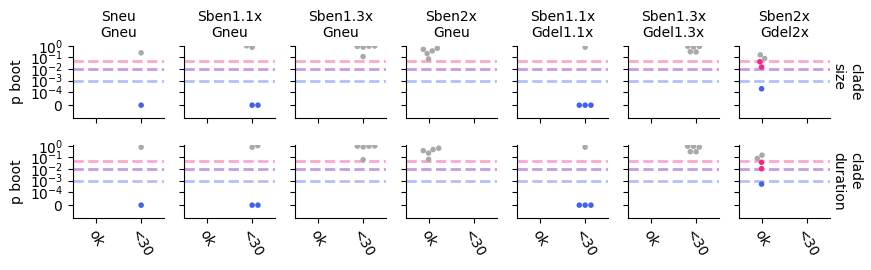

teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-binom+ext=.png


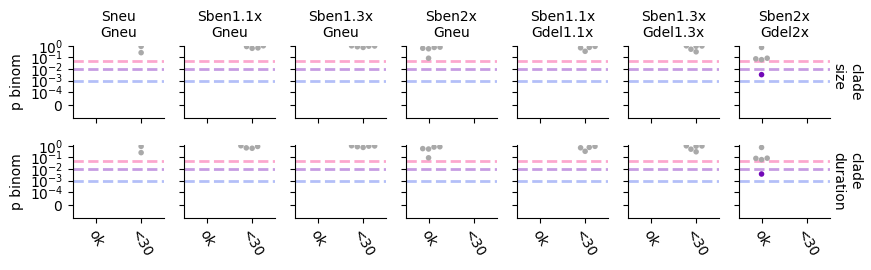

teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-mw+ext=.png


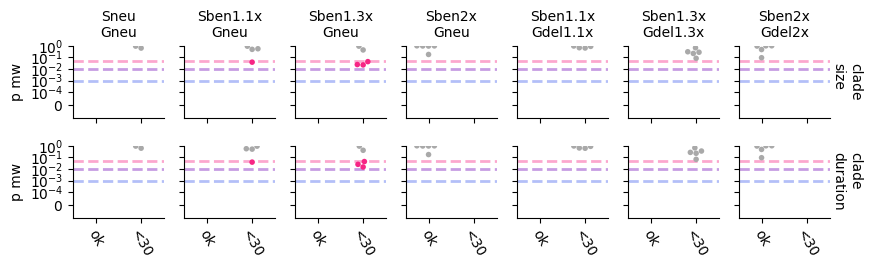

In [11]:
bins = [-np.inf, 0.001, 0.01, 0.05, np.inf]
labels = ["<0.001", "<0.01", "<0.05", "ns"]
gentle_palette = ["#4361EE", "#7209B7", "#F72585", "#A9A9A9"]

for y in "p_boot", "p_binom", "p_mw":
    display(HTML(f"<h1>{y=}</h1>"))

    data = results_df[
        (results_df["trt_hsurf_bits"] == 0)
        & (
            results_df["trt_n_downsample"]
            == results_df["trt_n_downsample"].max()
        )
        & (results_df["label"] != "all")
    ].copy()
    data["sig"] = pd.cut(
        data[y],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )
    data["sig"] = data["sig"].cat.set_categories(labels, ordered=True)
    data["smallsamp"] = data["n_grp"] < 30
    data["smallsamp"] = data["smallsamp"].map({True: "<30", False: "ok"})
    data["y_"] = (
        data["y"]
        .str.replace("month\n", "")
        .str.replace("num leaves", "clade\nsize")
        .str.replace("clade duration", "clade\nduration")
    )
    col_order = filter(
        set(data["trt_name_"]).__contains__,
        [
            "Sneu\nGneu",
            "Sben1.1x\nGneu",
            "Sben1.3x\nGneu",
            "Sben2x\nGneu",
            "Sben1.1x\nGdel1.1x",
            "Sben1.3x\nGdel1.3x",
            "Sben2x\nGdel2x",
        ],
    )
    col_order = [*col_order]
    with tp.teed(
        sns.catplot,
        data=data[
            data["y"].str.startswith("month").values
            & (data["label"] == "focal")
        ],
        y=y,
        col="trt_name_",
        row="y_",
        hue="sig",
        x="smallsamp",
        col_order=col_order,
        legend=False,
        kind="swarm",
        margin_titles=True,
        height=1.4,
        aspect=0.9,
        size=4,
        palette=gentle_palette,
        teeplot_outattrs={"comparator": "month"},
        teeplot_subdir=teeplot_subdir,
    ) as teed:

        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(
                0.05,
                alpha=0.4,
                color=gentle_palette[2],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.01,
                alpha=0.4,
                color=gentle_palette[1],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.001,
                alpha=0.4,
                color=gentle_palette[0],
                linestyle="--",
                linewidth=2,
            )
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()


teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.png


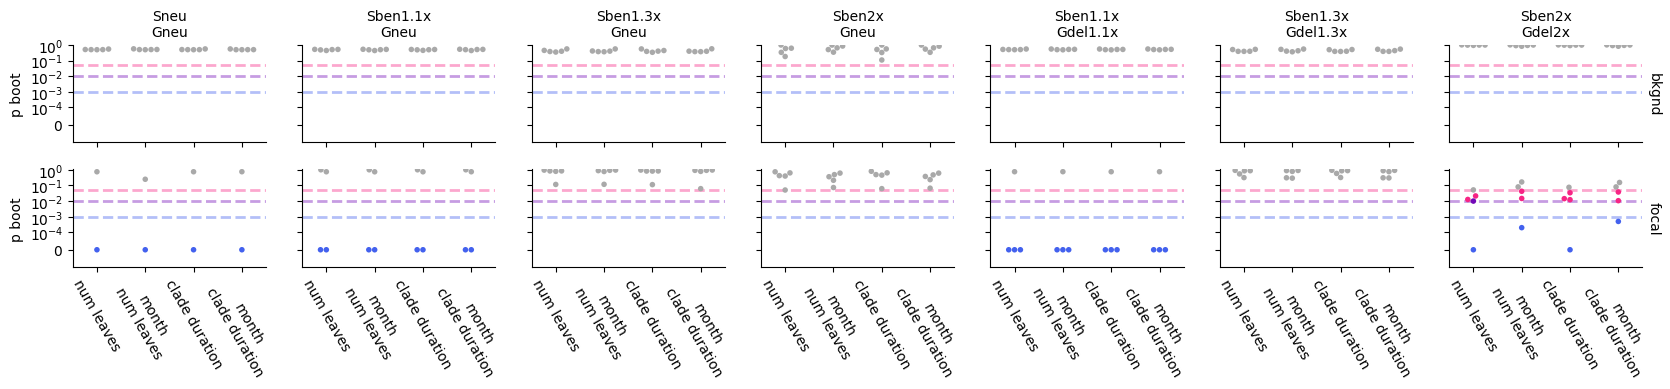

teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.png


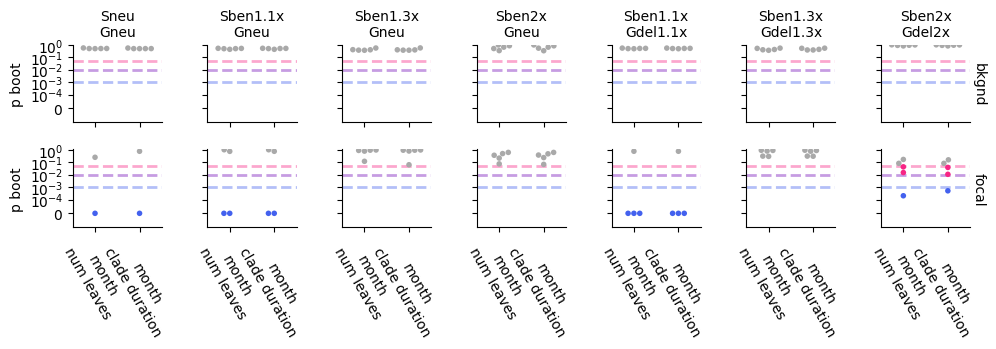

teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.png


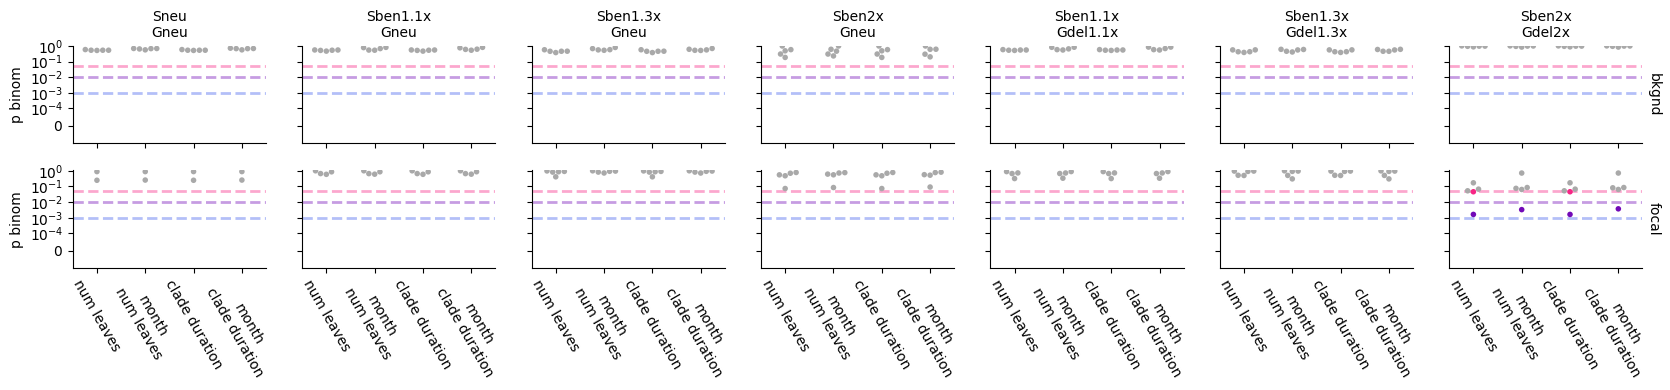

teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.png


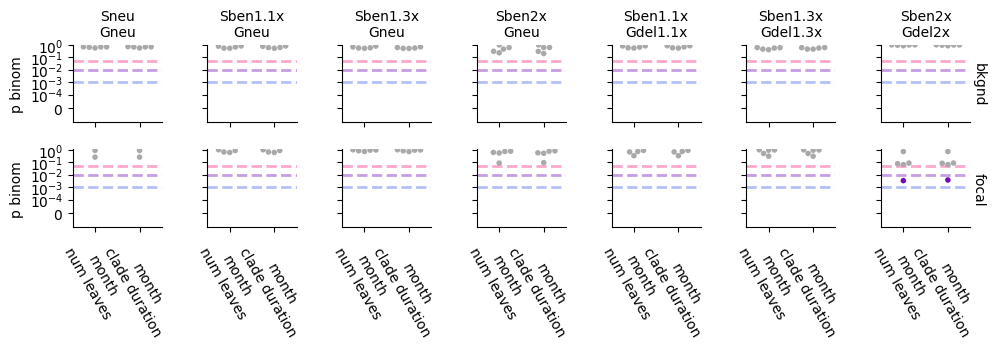

teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.png


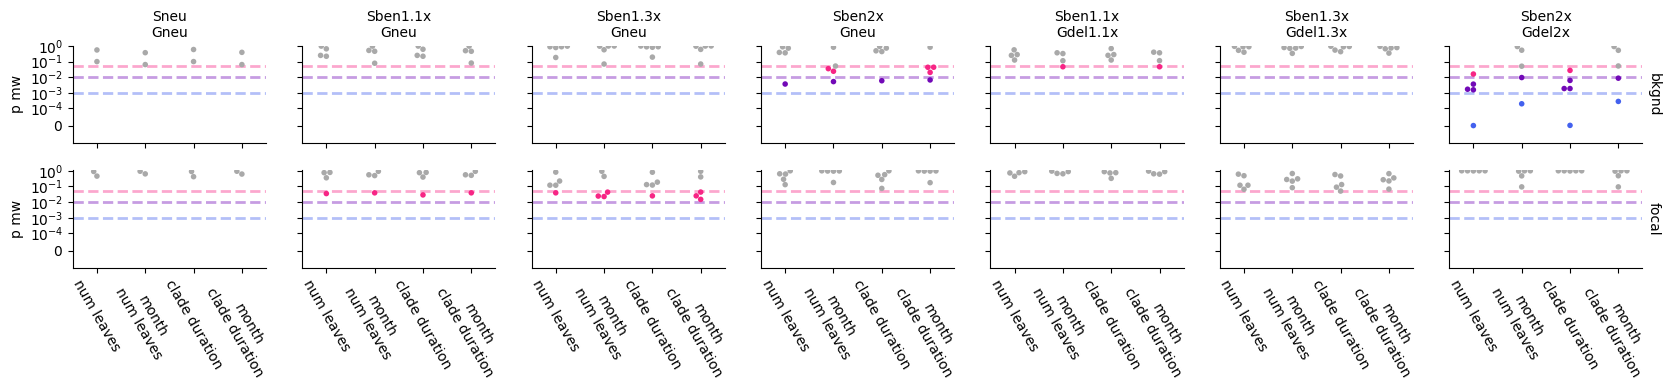

teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.png


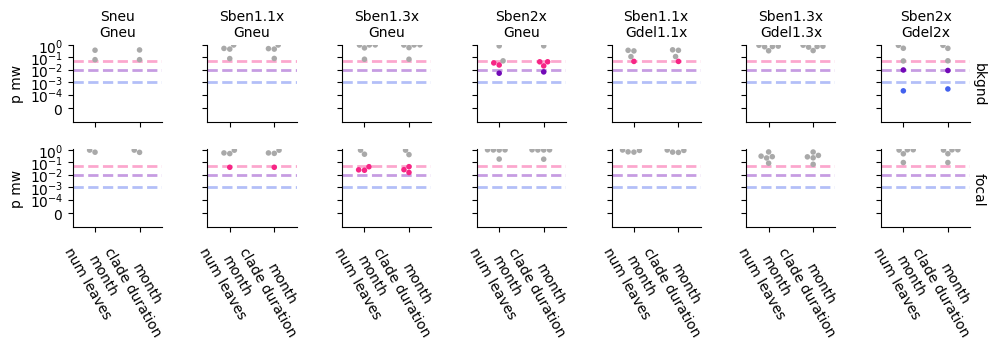

teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.pdf
teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.png


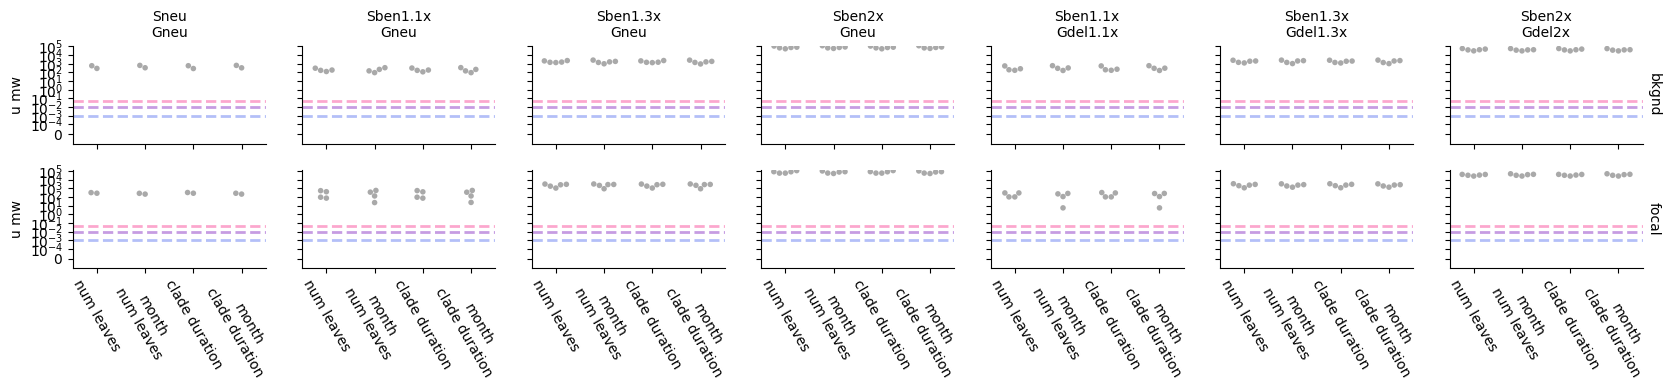

teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.pdf
teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.png


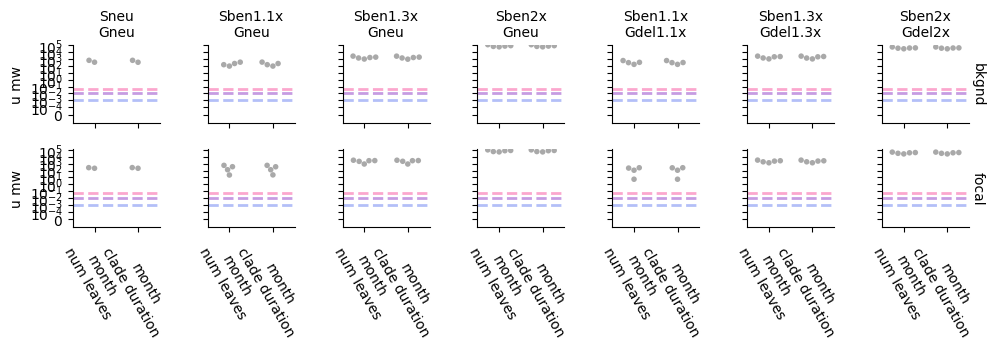

teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.pdf
teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.png


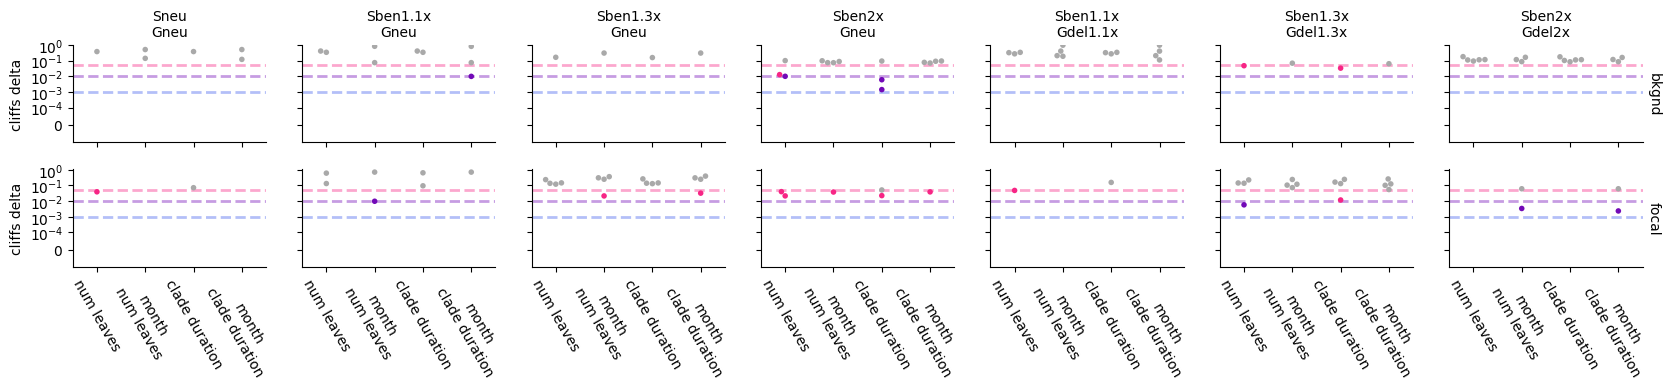

teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.pdf
teeplots/2025-05-19-compscreen-uk-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.png


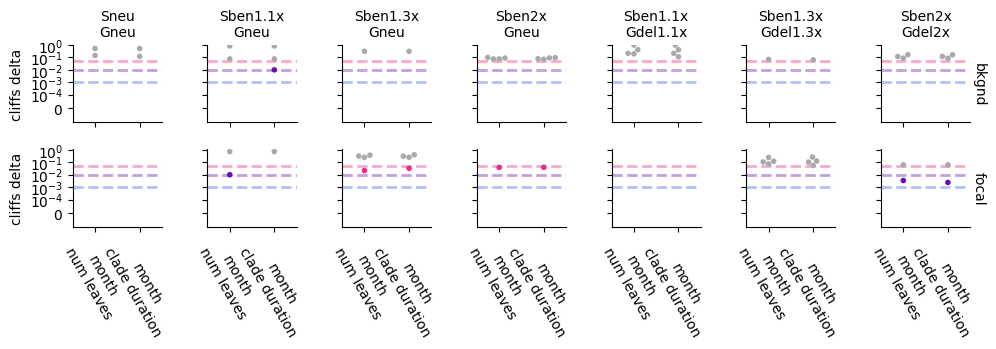

In [12]:
bins = [-np.inf, 0.001, 0.01, 0.05, np.inf]
labels = ["<0.001", "<0.01", "<0.05", "ns"]
gentle_palette = ["#4361EE", "#7209B7", "#F72585", "#A9A9A9"]


for y in "p_boot", "p_binom", "p_mw", "u_mw", "cliffs_delta":
    display(HTML(f"<h1>{y=}</h1>"))

    data = results_df[
        (results_df["trt_hsurf_bits"] == 0)
        & (
            results_df["trt_n_downsample"]
            == results_df["trt_n_downsample"].max()
        )
        & (results_df["label"] != "all")
    ].copy()
    data["sig"] = pd.cut(
        data[y],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )
    data["sig"] = data["sig"].cat.set_categories(labels, ordered=True)
    col_order = filter(
        set(data["trt_name_"]).__contains__,
        [
            "Sneu\nGneu",
            "Sben1.1x\nGneu",
            "Sben1.3x\nGneu",
            "Sben2x\nGneu",
            "Sben1.1x\nGdel1.1x",
            "Sben1.3x\nGdel1.3x",
            "Sben2x\nGdel2x",
        ],
    )
    col_order = [*col_order]
    with tp.teed(
        sns.catplot,
        data=data,
        y=y,
        x="y",
        col="trt_name_",
        row="label",
        hue="sig",
        col_order=col_order,
        legend=False,
        kind="swarm",
        margin_titles=True,
        height=2,
        aspect=1.2,
        palette=gentle_palette,
        size=4,
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(
                0.05,
                alpha=0.4,
                color=gentle_palette[2],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.01,
                alpha=0.4,
                color=gentle_palette[1],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.001,
                alpha=0.4,
                color=gentle_palette[0],
                linestyle="--",
                linewidth=2,
            )
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()

    with tp.teed(
        sns.catplot,
        data=data[data["y"].str.startswith("month").values],
        y=y,
        x="y",
        col="trt_name_",
        row="label",
        hue="sig",
        col_order=col_order,
        legend=False,
        kind="swarm",
        margin_titles=True,
        height=1.8,
        aspect=0.8,
        size=4,
        palette=gentle_palette,
        teeplot_outattrs={"comparator": "month"},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(
                0.05,
                alpha=0.4,
                color=gentle_palette[2],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.01,
                alpha=0.4,
                color=gentle_palette[1],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.001,
                alpha=0.4,
                color=gentle_palette[0],
                linestyle="--",
                linewidth=2,
            )
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()
